# LVBench pilot — policy vs perception

**The question:** the autonomous agent almost never looks where the evidence is. If we *hand* it the
right evidence, can it answer? That separates **policy** (where to look) from **perception**
(can it use what it sees).

**Arms** — all on the same seeded LVBench questions, same model, same 64-frame skim, same decoder.
After the 2026-07-27 audit fix, `oracle_crop` and `crop` now receive **byte-identical prompts**;
they differ only in *who picks the span*.

| arm | tools | who picks the span | role |
|---|---|---|---|
| `baseline` | none | — | base ability, no tools |
| `crop` | crop | **model** | native localization policy |
| `oracle_crop` | crop | harness, at the **GT evidence** | **is perception enough given perfect localization?** |
| `oracle_ctrl` | crop | harness, **same width, wrong place** | control: isolates *right* pixels from *more* pixels |

The `oracle_crop − oracle_ctrl` contrast is the one that matters: both inject exactly one crop of the
same width and token cost, so any gap is attributable to **location**, not budget.

In [1]:
import sys, os, json, glob
sys.path.insert(0,"/home/cfyang/hanklin/longvt_compression")
import numpy as np, matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from fast_agent import data, config, viz
from IPython.display import display, Markdown, Image

TAG="full"; RR=config.RUN_ROOT
ARMS=["baseline","crop","oracle_crop","oracle_ctrl"]
LAB={"baseline":"direct","crop":"auto-crop","oracle_crop":"oracle-crop","oracle_ctrl":"oracle-ctrl"}
COL={"baseline":"#888","crop":"#4C78A8","oracle_crop":"#2CA02C","oracle_ctrl":"#D62728"}

def load(a):
    p=os.path.join(RR,f"lvbench_{a}_{TAG}","results.jsonl")
    out={}
    for l in open(p):
        if l.strip():
            r=json.loads(l); out[str(r["question_id"])]=r
    return out
res={a:load(a) for a in ARMS}
# A row is USABLE only if the arm produced a real result (no top-level error).
# oracle_ctrl legitimately fails on questions whose evidence spans ~the whole video --
# a same-width "wrong place" cannot exist there, so localization is not a meaningful
# variable for those questions and they are excluded from EVERY arm, not just the control.
errored={a:{q for q,r in res[a].items() if r.get("error")} for a in ARMS}
excluded=set().union(*errored.values())
traj={}
for a in ARMS:
    traj[a]={t["question_id"]:t for t in viz.load_run(os.path.join(RR,f"lvbench_{a}_{TAG}"))}
lv={r["question_id"]:r for r in data.load_lvbench()}

# paired set = questions every arm has finished
common=sorted(set.intersection(*[set(res[a]) for a in ARMS]) - excluded, key=int)
print("per-arm completed:", {a:len(res[a]) for a in ARMS})
print("per-arm errored  :", {a:len(errored[a]) for a in ARMS})
print(f"excluded (whole-video evidence -> no valid control): {len(excluded)}")
print(f"PAIRED, ANALYSABLE set: n = {len(common)}")
def gt(q):
    ev=lv[q]["evidence"]; return (min(ev),max(ev))
def acc(a, qs): 
    qs=[q for q in qs if q in res[a]]
    return 100*sum(bool(res[a][q].get("correct")) for q in qs)/max(len(qs),1)


per-arm completed: {'baseline': 200, 'crop': 200, 'oracle_crop': 200, 'oracle_ctrl': 200}
per-arm errored  : {'baseline': 0, 'crop': 0, 'oracle_crop': 0, 'oracle_ctrl': 17}
excluded (whole-video evidence -> no valid control): 17
PAIRED, ANALYSABLE set: n = 183


## 1. Headline — accuracy on the paired set

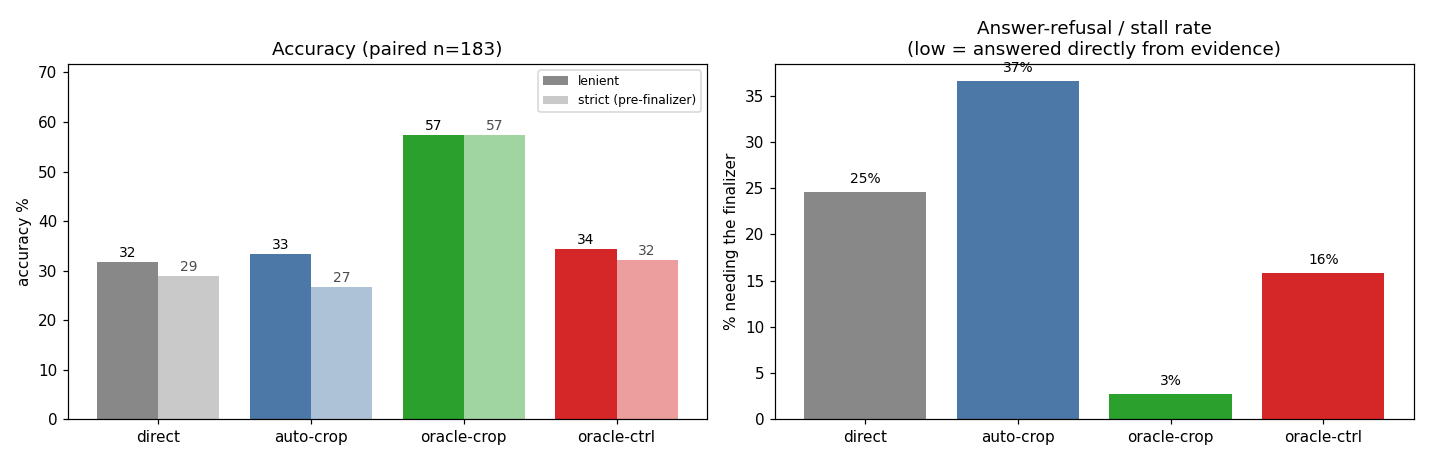

arm             lenient   strict  finalizer
direct            31.7%    29.0%      24.6%
auto-crop         33.3%    26.8%      36.6%
oracle-crop       57.4%    57.4%       2.7%
oracle-ctrl       34.4%    32.2%      15.8%


In [2]:
fig,axes=plt.subplots(1,2,figsize=(13,4.2))
ax=axes[0]
vals=[acc(a,common) for a in ARMS]
strict=[100*sum(bool(res[a][q].get("correct_strict")) for q in common)/len(common) for a in ARMS]
x=np.arange(len(ARMS))
ax.bar(x-0.2,vals,0.4,label="lenient",color=[COL[a] for a in ARMS])
ax.bar(x+0.2,strict,0.4,label="strict (pre-finalizer)",color=[COL[a] for a in ARMS],alpha=0.45)
for i,(v,s) in enumerate(zip(vals,strict)):
    ax.text(i-0.2,v+1,f"{v:.0f}",ha="center",fontsize=9); ax.text(i+0.2,s+1,f"{s:.0f}",ha="center",fontsize=9,alpha=.7)
ax.set_xticks(x); ax.set_xticklabels([LAB[a] for a in ARMS]); ax.set_ylabel("accuracy %")
ax.set_title(f"Accuracy (paired n={len(common)})"); ax.legend(fontsize=8); ax.set_ylim(0,max(vals+strict)*1.25)

ax=axes[1]
fin=[100*sum(bool(res[a][q].get("finalizer_used")) for q in common)/len(common) for a in ARMS]
ax.bar([LAB[a] for a in ARMS],fin,color=[COL[a] for a in ARMS])
for i,v in enumerate(fin): ax.text(i,v+1,f"{v:.0f}%",ha="center",fontsize=9)
ax.set_ylabel("% needing the finalizer"); ax.set_title("Answer-refusal / stall rate\n(low = answered directly from evidence)")
plt.tight_layout(); plt.savefig("/tmp/_p1.png",dpi=110); plt.close()
display(Image("/tmp/_p1.png"))

print(f"{'arm':14s} {'lenient':>8s} {'strict':>8s} {'finalizer':>10s}")
for a,v,s,f in zip(ARMS,vals,strict,fin): print(f"{LAB[a]:14s} {v:>7.1f}% {s:>7.1f}% {f:>9.1f}%")


## 2. The decisive contrast — does **location** matter, or just more pixels?

`oracle_crop` and `oracle_ctrl` inject one crop each, identical width and token cost. The only
difference is whether it lands on the evidence. This is the control the audit demanded: without it,
any oracle gain is equally explained by "more visual tokens of any content".

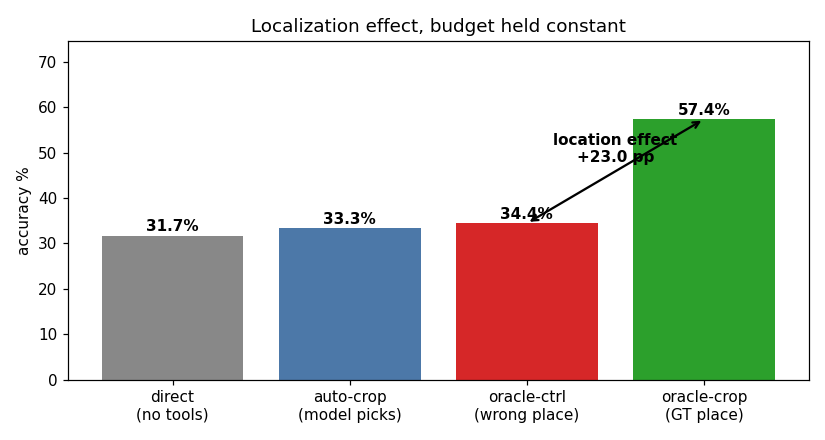

oracle_crop - oracle_ctrl = +23.0 pp
  discordant: oracle-only-right=51, ctrl-only-right=9  exact McNemar p=0.000
oracle_crop - direct      = +25.7 pp
auto-crop  - direct       = +1.6 pp


In [3]:
oc,ct=acc("oracle_crop",common),acc("oracle_ctrl",common)
base,auto=acc("baseline",common),acc("crop",common)
fig,ax=plt.subplots(figsize=(7.5,4))
bars=["direct\n(no tools)","auto-crop\n(model picks)","oracle-ctrl\n(wrong place)","oracle-crop\n(GT place)"]
vv=[base,auto,ct,oc]; cc=["#888",COL["crop"],COL["oracle_ctrl"],COL["oracle_crop"]]
ax.bar(bars,vv,color=cc)
for i,v in enumerate(vv): ax.text(i,v+1,f"{v:.1f}%",ha="center",fontweight="bold")
ax.set_ylabel("accuracy %"); ax.set_ylim(0,max(vv)*1.3)
ax.set_title("Localization effect, budget held constant")
ax.annotate("", xy=(3,oc), xytext=(2,ct), arrowprops=dict(arrowstyle="<->",color="k",lw=1.5))
ax.text(2.5,(oc+ct)/2+2,f"location effect\n{oc-ct:+.1f} pp",ha="center",fontsize=10,fontweight="bold")
plt.tight_layout(); plt.savefig("/tmp/_p2.png",dpi=110); plt.close(); display(Image("/tmp/_p2.png"))

# paired McNemar on the decisive contrast
b=sum(1 for q in common if res["oracle_crop"][q].get("correct") and not res["oracle_ctrl"][q].get("correct"))
c=sum(1 for q in common if res["oracle_ctrl"][q].get("correct") and not res["oracle_crop"][q].get("correct"))
from math import comb
p=sum(comb(b+c,k) for k in range(min(b,c)+1))*2/(2**(b+c)) if (b+c) else 1.0
print(f"oracle_crop - oracle_ctrl = {oc-ct:+.1f} pp")
print(f"  discordant: oracle-only-right={b}, ctrl-only-right={c}  exact McNemar p={min(p,1.0):.3f}")
print(f"oracle_crop - direct      = {oc-base:+.1f} pp")
print(f"auto-crop  - direct       = {auto-base:+.1f} pp")


## 3. Where did the autonomous agent actually look?

GT-coverage = fraction of the ground-truth evidence span covered by the union of the spans the
**model itself chose**. This is what LVBench uniquely enables.

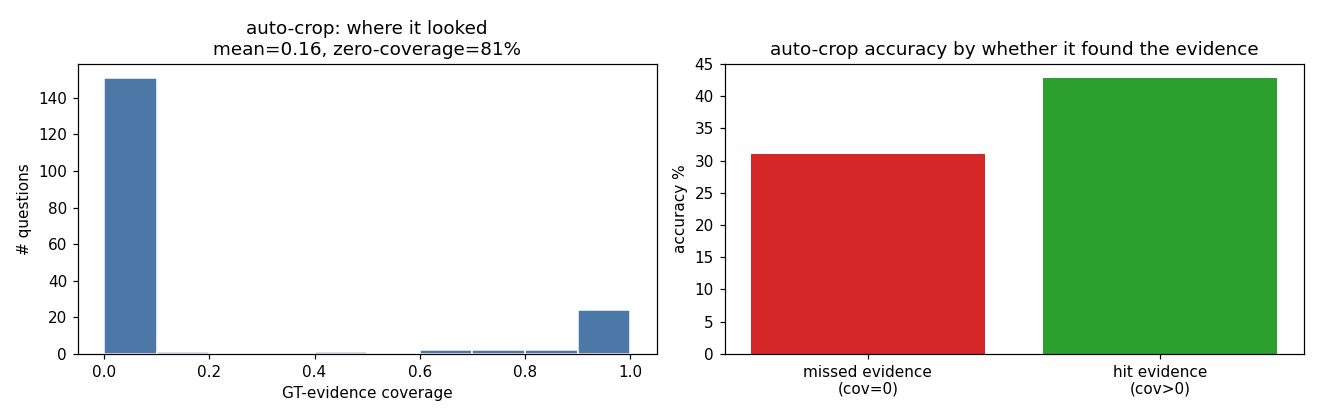

auto-crop mean GT-coverage = 0.160   |  zero-coverage on 148/183 questions


In [4]:
def cover(spans,g):
    if not spans: return 0.0
    gs,ge=g; L=max(ge-gs,1e-6)
    segs=sorted([(max(s,gs),min(e,ge)) for s,e in spans if min(e,ge)>max(s,gs)])
    tot=0.0;cur=None
    for s,e in segs:
        if cur is None: cur=[s,e]
        elif s<=cur[1]: cur[1]=max(cur[1],e)
        else: tot+=cur[1]-cur[0];cur=[s,e]
    if cur: tot+=cur[1]-cur[0]
    return tot/L
covs=[]
for q in common:
    sp=[(c["start"],c["end"]) for c in res["crop"][q].get("tool_calls",[])]
    covs.append((q,cover(sp,gt(q)),bool(res["crop"][q].get("correct")),len(sp)))
cv=np.array([c for _,c,_,_ in covs])
fig,ax=plt.subplots(1,2,figsize=(12,3.8))
ax[0].hist(cv,bins=np.linspace(0,1,11),color=COL["crop"],edgecolor="w")
ax[0].set_xlabel("GT-evidence coverage"); ax[0].set_ylabel("# questions")
ax[0].set_title(f"auto-crop: where it looked\nmean={cv.mean():.2f}, zero-coverage={100*(cv==0).mean():.0f}%")
zero=(cv==0); 
ax[1].bar(["missed evidence\n(cov=0)","hit evidence\n(cov>0)"],
          [100*np.mean([c for (_,_,c,_),z in zip(covs,zero) if z] or [0]),
           100*np.mean([c for (_,_,c,_),z in zip(covs,zero) if not z] or [0])],
          color=["#D62728","#2CA02C"])
ax[1].set_ylabel("accuracy %"); ax[1].set_title("auto-crop accuracy by whether it found the evidence")
plt.tight_layout(); plt.savefig("/tmp/_p3.png",dpi=110); plt.close(); display(Image("/tmp/_p3.png"))
print(f"auto-crop mean GT-coverage = {cv.mean():.3f}   |  zero-coverage on {int((cv==0).sum())}/{len(cv)} questions")


## 4. The training-justifying pattern

```
direct wrong  +  autonomous wrong  +  oracle(GT) right   ->  the evidence works, the POLICY is missing
```
The control tells us how much of that is genuine: subtract the cases where `oracle_ctrl` (wrong place)
*also* got it right, since those were never about localization.

direct-wrong & auto-wrong & oracle-RIGHT : 41/183 = 22%
   ...and control also wrong (attributable to LOCATION): 32 = 17%
   qids: ['61', '121', '286', '509', '664', '673', '746', '799', '850', '860', '1120', '1631', '2262', '2270', '2367', '2370', '2400', '2493', '2573', '2822', '2965', '3040', '3946', '4178', '4305', '4352', '4462', '4678', '4692', '4760', '4789', '4969']

wrong in EVERY arm (perception/annotation ceiling): 55/183 = 30%
   qids: ['28', '35', '65', '68', '120', '128', '251', '268', '303', '804', '813', '991', '995', '1174', '1246']


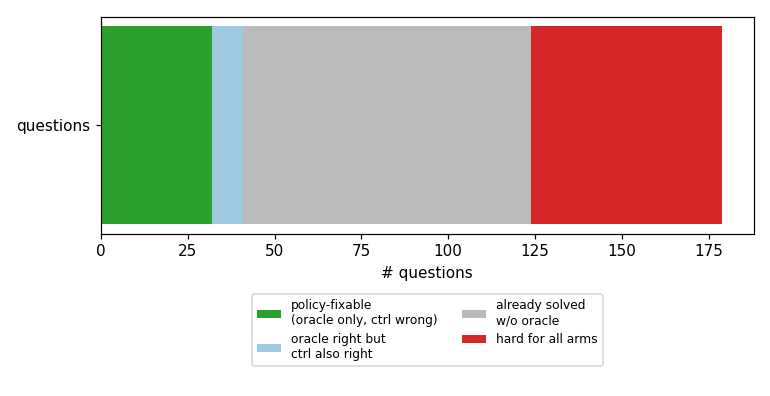

In [5]:
pat=[q for q in common if not res["baseline"][q].get("correct")
       and not res["crop"][q].get("correct") and res["oracle_crop"][q].get("correct")]
pat_clean=[q for q in pat if not res["oracle_ctrl"][q].get("correct")]
hard=[q for q in common if not any(res[a][q].get("correct") for a in ARMS)]
print(f"direct-wrong & auto-wrong & oracle-RIGHT : {len(pat)}/{len(common)} = {100*len(pat)/len(common):.0f}%")
print(f"   ...and control also wrong (attributable to LOCATION): {len(pat_clean)} = {100*len(pat_clean)/len(common):.0f}%")
print(f"   qids: {pat_clean}")
print(f"\nwrong in EVERY arm (perception/annotation ceiling): {len(hard)}/{len(common)} = {100*len(hard)/len(common):.0f}%")
print(f"   qids: {hard[:15]}")

fig,ax=plt.subplots(figsize=(7,3.6))
seg=[len(pat_clean), len(pat)-len(pat_clean),
     len([q for q in common if res["baseline"][q].get("correct") or res["crop"][q].get("correct")]),
     len(hard)]
lbl=["policy-fixable\n(oracle only, ctrl wrong)","oracle right but\nctrl also right","already solved\nw/o oracle","hard for all arms"]
ax.barh(["questions"],[seg[0]],color="#2CA02C",label=lbl[0])
left=seg[0]
for v,c,l in zip(seg[1:],["#9ecae1","#bbb","#D62728"],lbl[1:]):
    ax.barh(["questions"],[v],left=left,color=c,label=l); left+=v
ax.set_xlabel("# questions"); ax.legend(fontsize=8,ncol=2,loc="upper center",bbox_to_anchor=(.5,-.25))
plt.tight_layout(); plt.savefig("/tmp/_p4.png",dpi=110); plt.close(); display(Image("/tmp/_p4.png"))


## 5. Stratification — trivial questions, evidence width, task type

In [6]:
triv=[q for q in common if lv[q].get("localization_trivial")]
nont=[q for q in common if not lv[q].get("localization_trivial")]
print(f"{'stratum':28s} {'n':>4s} " + " ".join(f"{LAB[a]:>12s}" for a in ARMS))
for name,qs in [("ALL",common),("localization-trivial",triv),("non-trivial",nont)]:
    if not qs: continue
    print(f"{name:28s} {len(qs):>4d} " + " ".join(f"{acc(a,qs):>11.1f}%" for a in ARMS))
w=[(q, gt(q)[1]-gt(q)[0]) for q in common]
narrow=[q for q,x in w if x<60]; wide=[q for q,x in w if x>=60]
for name,qs in [("evidence <60s",narrow),("evidence >=60s",wide)]:
    if qs: print(f"{name:28s} {len(qs):>4d} " + " ".join(f"{acc(a,qs):>11.1f}%" for a in ARMS))
print()
import collections
byt=collections.defaultdict(list)
for q in common: byt[lv[q]["task_type"]].append(q)
for t,qs in sorted(byt.items(), key=lambda kv:-len(kv[1])):
    if len(qs)>=3: print(f"{t:28s} {len(qs):>4d} " + " ".join(f"{acc(a,qs):>11.1f}%" for a in ARMS))


stratum                         n       direct    auto-crop  oracle-crop  oracle-ctrl
ALL                           183        31.7%        33.3%        57.4%        34.4%
localization-trivial           26        38.5%        57.7%        57.7%        34.6%
non-trivial                   157        30.6%        29.3%        57.3%        34.4%
evidence <60s                 140        28.6%        32.9%        58.6%        34.3%
evidence >=60s                 43        41.9%        34.9%        53.5%        34.9%

event understanding            67        32.8%        34.3%        53.7%        32.8%
entity recognition             65        30.8%        29.2%        61.5%        30.8%
key information retrieval      23        34.8%        34.8%        65.2%        47.8%
reasoning                      15        33.3%        33.3%        40.0%        33.3%
summarization                   7        14.3%        57.1%        42.9%         0.0%
temporal grounding              6        33.3%       

## 6. Per-question outcome matrix

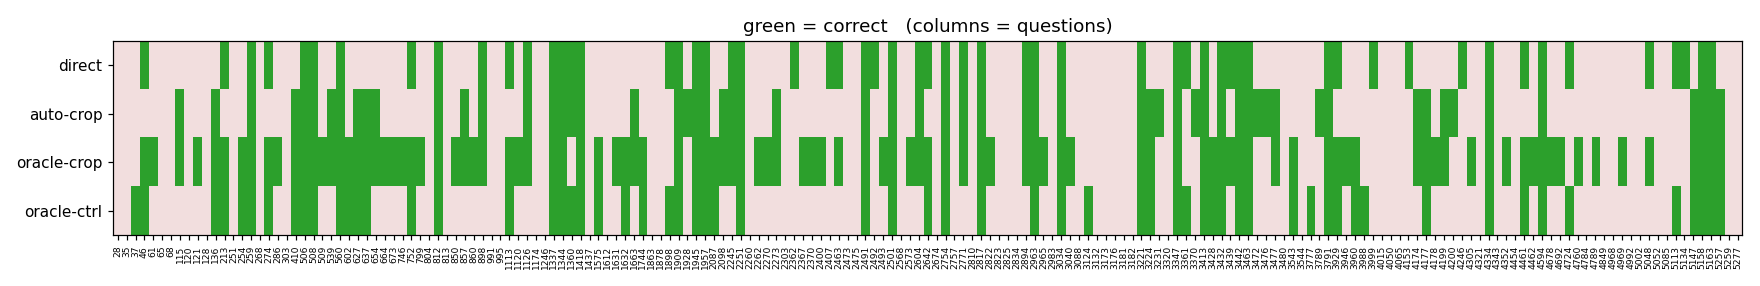

In [7]:
fig,ax=plt.subplots(figsize=(min(16,0.3*len(common)+3),2.6))
M=np.array([[1 if res[a][q].get("correct") else 0 for q in common] for a in ARMS])
ax.imshow(M,aspect="auto",cmap=matplotlib.colors.ListedColormap(["#f2dede","#2CA02C"]),vmin=0,vmax=1)
ax.set_yticks(range(len(ARMS))); ax.set_yticklabels([LAB[a] for a in ARMS])
ax.set_xticks(range(len(common))); ax.set_xticklabels(common,rotation=90,fontsize=6)
ax.set_title("green = correct   (columns = questions)")
plt.tight_layout(); plt.savefig("/tmp/_p6.png",dpi=110); plt.close(); display(Image("/tmp/_p6.png"))


## 7. The decisive cases, up close

For each question where **only the GT-located oracle** got it right (control wrong), show what the
model was given and what it said. This is the SFT-candidate set.

---
### qid 61 — summarization — gold **A** — GT `04:19-08:41`

After the man with the gun threatens the cook, what does the protagonist do?
A. The protagonist pushes the table aside and stands up, confronting the man. After a series of quarrels, she kills the man and leaves the restaurant. The chef follows her
B. The protagonist pushes the table aside and stands up, confronting the man. After a series of quarrels, she injuries  the man and leaves the restaurant. The chef follows her
C. The protagonist pushes the table aside and stands up, taking out her gun and pointing at the man. After a series of quarrels, she kills the man and leaves the restaurant. The chef follows her
D. The protagonist pushes the table aside and stands up, taking out her gun and pointing at the man. After a series of quarrels, she kills the man and leaves the restaurant

direct=Bx | auto-crop=Bx | oracle-crop=AOK | oracle-ctrl=Nonex
  --- auto-crop ---
   [answer] I need to analyze the sequence of events after the man with the gun threatens the cook. I'll look for the frames where the protagonist reacts to this threat.  Looking at the provided frames, I can see a scene where a man is holding a gun to a cook's head (fram
  --- oracle-ctrl ---
   CALL crop_video(3144,3406) [FORCED]
   [answer] The provided video frames do not contain any scene where a man with a gun threatens a cook, nor do they show the protagonist pushing a table aside, confronting the man, or any subsequent events like killing or leaving the restaurant. The frames depict various 
   [finalizer] <answer>None of the above</answer>
  --- oracle-crop ---
   CALL crop_video(259,521) [FORCED]
   [answer] The protagonist, wearing a wide-brimmed hat and glasses, is shown standing calmly as the man with the gun threatens the cook. She does not immediately react with violence. Instead, she calm

**GT evidence shown to oracle-crop:**

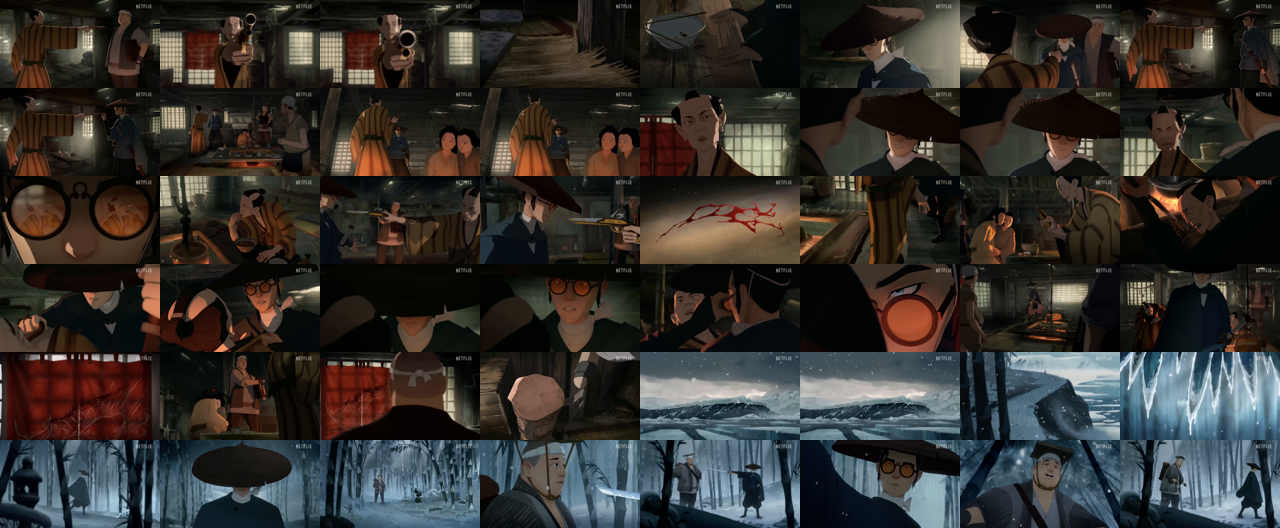

---
### qid 121 — event understanding — gold **D** — GT `05:15-05:31`

Why does the man follow the woman in red after they meet for the third time?
A. He falls in love with the woman
B. He is a spy
C. The woman has his phone
D. The woman has his book

direct=Ax | auto-crop=Ax | oracle-crop=DOK | oracle-ctrl=Ax
  --- auto-crop ---
   (none)
  --- oracle-ctrl ---
   (none)
  --- oracle-crop ---
   (none)


---
### qid 286 — entity recognition — gold **B** — GT `36:23-36:23`

An ant and a spider go sailing. What is inside the cabin?
A. IMac
B. IPod
C. IPad
D. IPhone

direct=Nonex | auto-crop=Ax | oracle-crop=BOK | oracle-ctrl=Ax
  --- auto-crop ---
   CALL crop_video(43,130)
   CALL crop_video(130,216)
   CALL crop_video(216,303)
   CALL crop_video(303,389)
   CALL crop_video(389,476)
   [stop] The frames from 389s to 476s show ladybugs flying, a spider on its web, and a snowy forest. This is part of the story, but I have not yet found the ship or its cabin. I need to continue searching.  I'll now look for the ship. I'll check frames around 476 secon
   [finalizer] <answer>A</answer>
  --- oracle-ctrl ---
   CALL crop_video(3343,3359) [FORCED]
   [answer] <answer>A</answer>
  --- oracle-crop ---
   CALL crop_video(2175,2191) [FORCED]
   [answer] <answer>B</answer>


**GT evidence shown to oracle-crop:**

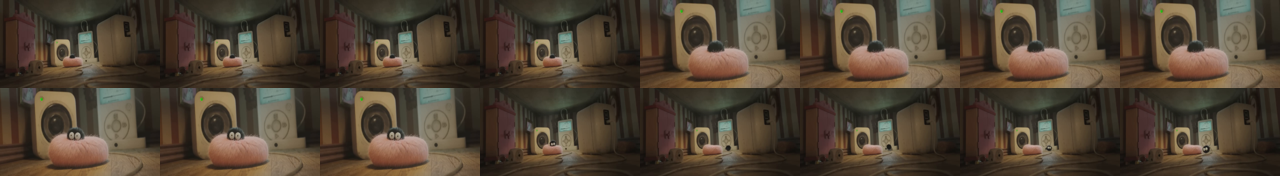

---
### qid 509 — entity recognition — gold **B** — GT `03:46-03:47`

How many mice run across the roof above the street?
A. 5
B. 2
C. 3
D. 1

direct=Cx | auto-crop=Nonex | oracle-crop=BOK | oracle-ctrl=Dx
  --- auto-crop ---
   CALL crop_video(270,327)
   CALL crop_video(356,413)
   CALL crop_video(441,498)
   CALL crop_video(527,584)
   CALL crop_video(612,669)
   [stop] I've reviewed the frames from 612s to 669s, but I still haven't found the scene with mice running across the roof above the street. I need to continue searching. I will now check the frames around 697 seconds.  <tool_call> {"name": "crop_video", "arguments": {
   [finalizer] I've reviewed the frames from 697s to 754s, but I still haven't found the scene with mice running across the roof above the street. I need to continue searching. I will now check the frames around 783 seconds.  <tool_call> {"name": "crop_video", "arguments": {
  --- oracle-ctrl ---
   CALL crop_video(1588,1604) [FORCED]
   [answer] <answer>D</answer>
  --- oracle-crop ---
   CALL crop_video(218,234) [FORCED]
   [answer] <answer>B</answer>


**GT evidence shown to oracle-crop:**

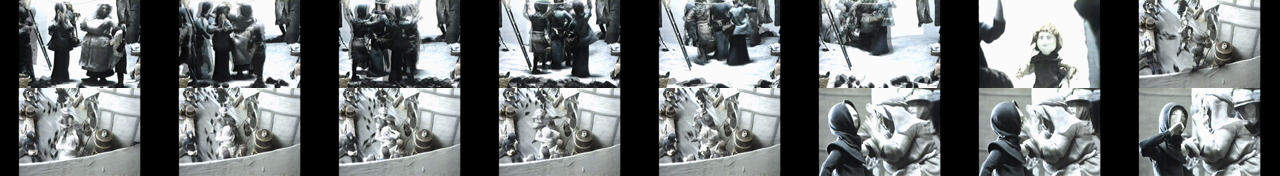

---
### qid 664 — event understanding — gold **D** — GT `17:49-17:55`

What happens when the boy at the vending machine is about to press the button?
A. The girl with long purple hair appears in the vending machine
B. The girl with long red hair appears in the vending machine
C. The girl with long black hair appears in the vending machine
D. The girl with short blond hair appears in the vending machine

direct=Nonex | auto-crop=Nonex | oracle-crop=DOK | oracle-ctrl=Nonex
  --- auto-crop ---
   (none)
  --- oracle-ctrl ---
   (none)
  --- oracle-crop ---
   (none)


---
### qid 673 — entity recognition — gold **B** — GT `36:50-37:16`

What changes do the people in the hall share?
A. Their hair is partly green
B. Their hair is partly light yellow
C. Their hair is partly light blue
D. Their hair is partly red

direct=Dx | auto-crop=Nonex | oracle-crop=BOK | oracle-ctrl=Dx
  --- auto-crop ---
   CALL crop_video(4908,4986)
   CALL crop_video(1296,1374)
   CALL crop_video(1688,1767)
   CALL crop_video(2081,2160)
   CALL crop_video(2395,2474)
   [stop] The frames from 2395s to 2474s show a scene inside a spaceship or aircraft, not a hall. I need to find a scene with people in a hall. Let me check the frame at 2709s, which shows a group of people in a hall.  <tool_call> {"name": "crop_video", "arguments": {"s
   [finalizer] The frames from 2709s to 2788s show a scene with three women in a hall or large room. I can see their hair colors: one has black hair, one has blonde hair, and one has red hair. This doesn't show a shared change.  Let me check another scene. I'll look at the f
  --- oracle-ctrl ---
   CALL crop_video(2790,2816) [FORCED]
   [answer] <answer>D</answer>
  --- oracle-crop ---
   CALL crop_video(2210,2236) [FORCED]
   [answer] <answer>B</answer>


**GT evidence shown to oracle-crop:**

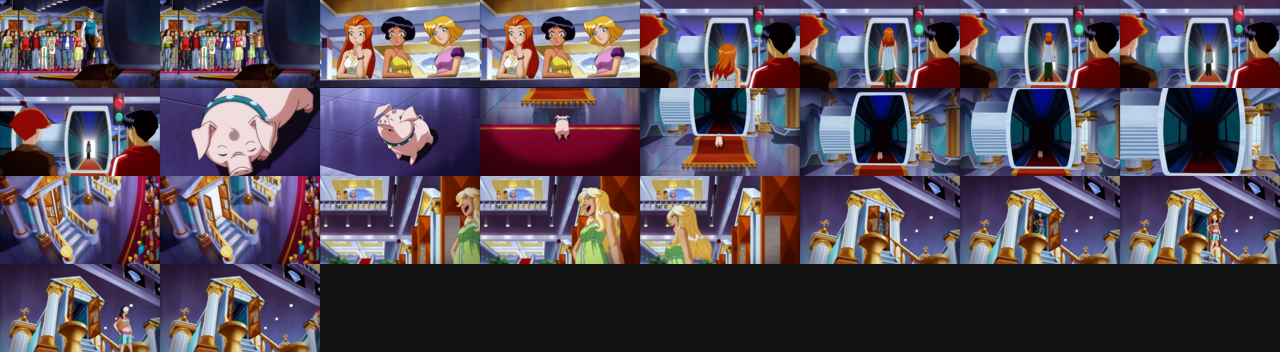

In [8]:
def think(a,q):
    t=traj[a].get(q) or {}; out=[]
    for r in t.get("rounds",[]):
        act=r.get("action") or {}; k=act.get("kind"); tx=(r.get("thinking") or "").strip().replace("\n"," ")
        if k=="tool_call": out.append(f"   CALL {act['name']}({act['start']:.0f},{act['end']:.0f})"+(" [FORCED]" if act.get("oracle_forced") else ""))
        elif k in ("answer","stop","finalizer"): out.append(f"   [{k}] {tx[:260]}")
    return "\n".join(out) or "   (none)"

for q in pat_clean[:6]:
    row=lv[q]
    display(Markdown(f"---\n### qid {q} — {row['task_type']} — gold **{row['answer']}** — GT `{row['time_reference']}`\n\n"
                     f"{data.format_question(row)}"))
    print(" | ".join(f"{LAB[a]}={res[a][q].get('pred')}{'OK' if res[a][q].get('correct') else 'x'}" for a in ARMS))
    for a in ["crop","oracle_ctrl","oracle_crop"]:
        print(f"  --- {LAB[a]} ---"); print(think(a,q))
    t=traj["oracle_crop"].get(q) or {}
    for r in t.get("rounds",[]):
        tr=r.get("tool_result") or {}
        if tr.get("montage") and os.path.exists(tr["montage"]):
            display(Markdown(f"**GT evidence shown to oracle-crop:**")); display(Image(filename=tr["montage"],width=1000))


## 8. How to read this

- **`oracle_crop − oracle_ctrl`** is the only clean localization estimate. Both arms get one crop of
  identical width and token cost; only the location differs. A large positive gap ⇒ the evidence is
  usable and the missing piece is *finding* it. A gap near zero ⇒ extra pixels help regardless of
  where they come from, and the localization story is not supported.
- **`oracle_crop − direct`** is *not* clean on its own — the oracle sees strictly more visual tokens.
  Always read it next to the control.
- **Finalizer rate** matters: an arm that answers only after being coerced into emitting a letter is
  guessing, not reading evidence. Compare it alongside accuracy.
- **n here is small.** Treat every gap as directional until the full run. The continuous GT-coverage
  metric (§3) is far more sample-efficient than binary accuracy — trust it earlier.
- Questions whose text contains their own timestamp (§5, ~13%) are localization-trivial by
  construction; the non-trivial stratum is the honest number.